# Antenna Tilt Optimization with QAOA on Real Cell-Tower Data

Cellular operators steer the *down-tilt* of every sector antenna to trade coverage against
interference with neighbouring sectors. Tilts are set from a small discrete menu, so a site
cluster of $n$ antennas with $L$ tilt levels has $L^n$ plans, and the objective couples every
pair of antennas. This notebook solves a small real instance with QAOA on Classiq:

* **Data**: 6 sector antennas on 2 real Tel Aviv sites taken from the OpenCelliD open database
  (CC BY-SA 4.0). Tilt angles and interference are not public, so they are modelled from the
  tower geometry (documented below).
* **Encoding**: 4 tilt levels per antenna as one `QNum[2]` register, i.e. **2 qubits per
  antenna, 12 qubits, 4096 plans**. Every basis state is a valid plan, so no penalty terms are
  needed.
* **Cost**: a quadratic form written directly on the quantum numbers; Classiq's `phase`
  function compiles it into the QAOA phase separator (73 Pauli terms: 1 I + 12 Z + 60 ZZ).
* **Warm start**: the QAOA angles are *hot-started* from an exact statevector optimisation done
  offline in Wolfram Mathematica, and the classical optimum used as reference was certified in
  Lean 4. The Classiq run reproduces the predicted statistics and then refines the angles with
  COBYLA in an `ExecutionSession`.

The notebook is the Classiq leaf of a larger, hierarchical workflow (k-means grouping of a city's
interaction regions, one QAOA per representative region); see the project repository linked at
the end.

## 1. The instance

Six antennas: site 0 has three sectors (azimuth 0/120/240 degrees) at (32.0735 N, 34.7904 E),
site 1 has three sectors at (32.0870 N, 34.8046 E), 1.9 km apart. Each antenna $i$ has a
coverage gain $c_i$ (from the distance to its nearest neighbour site) and the pair coupling
$I_{ij}$ is strong inside a site (1.35, the three sectors overlap) and weak between the sites
(about 0.18, exponential decay with distance).

For a tilt vector $t \in \{0,1,2,3\}^6$ the cost to minimise is

$$
\mathrm{Cost}(t) \;=\; t^{\mathsf T} I\, t \;-\; \lambda\, c^{\mathsf T} t \;+\; \mu \sum_i t_i ,
\qquad \lambda = 1.5,\; \mu = 0.3 .
$$

Tilting an antenna down (larger $t_i$) reduces its interference footprint, which is rewarded
through $c_i$, but tilting *everything* down leaves dead zones (the $\mu$ term) and the quadratic
term punishes two neighbours that both tilt aggressively into the same area.

In [1]:
import numpy as np

LAMBDA, MU = 1.5, 0.3
N_ANT, LEVELS = 6, 4
QUBITS_PER_ANT = 2

# coverage gain per antenna (OpenCelliD sites, Tel Aviv, MCC 425)
CVEC = np.array([0.815, 0.832, 0.815, 0.800, 0.800, 0.800])

# interference coupling I_ij (symmetric, zero diagonal)
IMAT = np.array(
    [
        [0.0, 1.35, 1.35, 0.1807, 0.1807, 0.1807],
        [1.35, 0.0, 1.35, 0.1851, 0.1851, 0.1851],
        [1.35, 1.35, 0.0, 0.1741, 0.1741, 0.1741],
        [0.1807, 0.1851, 0.1741, 0.0, 1.35, 1.35],
        [0.1807, 0.1851, 0.1741, 1.35, 0.0, 1.35],
        [0.1807, 0.1851, 0.1741, 1.35, 1.35, 0.0],
    ]
)


def cost_of(t):
    t = np.asarray(t, dtype=float)
    return float(t @ IMAT @ t - LAMBDA * (CVEC @ t) + MU * t.sum())

### Classical reference

With 4096 plans the instance is small enough to enumerate, which gives us an exact reference to
judge the quantum samples against. The optimum is unique: only antenna 1 (the sector with the
largest coverage gain) is tilted fully down, all others stay at level 0.

In [2]:
import itertools

all_plans = list(itertools.product(range(LEVELS), repeat=N_ANT))
costs = np.array([cost_of(t) for t in all_plans])
opt_idx = int(costs.argmin())
OPT_T, OPT_C = all_plans[opt_idx], float(costs[opt_idx])
n_optima = int((costs == OPT_C).sum())

print(
    f"{len(all_plans)} plans, optimum cost {OPT_C:.4f} at tilts {list(OPT_T)} ({n_optima} optimum)"
)
print(
    f"uniform sampling: P(optimum) = {1/len(all_plans):.5f}, P(cost<0) = {(costs < 0).mean():.3f}, <cost> = {costs.mean():.4f}"
)

4096 plans, optimum cost -2.8440 at tilts [0, 3, 0, 0, 0, 0] (1 optimum)
uniform sampling: P(optimum) = 0.00024, P(cost<0) = 0.024, <cost> = 35.4992


## 2. The QAOA model in Qmod

Each antenna is a `QNum[2]` (an unsigned 2-bit quantum integer holding the tilt level 0..3); the
six of them live in a `QStruct`. The cost is written as an ordinary arithmetic expression on these
quantum numbers and `phase(expr, gamma)` applies $e^{i\gamma\,\mathrm{Cost}(t)}$. Classiq expands
the expression into its Pauli decomposition and synthesises the phase layer; the mixer is an `RX`
on every qubit. The angles are classical execution parameters (`CArray[CReal]`), so one synthesised
program serves the whole optimisation loop.

In [3]:
from classiq import *

NUM_LAYERS = 1


class TiltVars(QStruct):
    tilts: QArray[QNum[QUBITS_PER_ANT], N_ANT]


def tilt_cost(t: TiltVars):
    expr = 0
    for i in range(N_ANT):
        for j in range(N_ANT):
            if IMAT[i, j] != 0.0:
                expr += float(IMAT[i, j]) * t.tilts[i] * t.tilts[j]
        expr += (MU - LAMBDA * float(CVEC[i])) * t.tilts[i]
    return expr


@qfunc
def main(params: CArray[CReal, 2 * NUM_LAYERS], t: Output[TiltVars]) -> None:
    allocate(t)
    hadamard_transform(t)
    repeat(
        count=NUM_LAYERS,
        iteration=lambda i: (
            phase(tilt_cost(t), params[2 * i]),
            apply_to_all(lambda q: RX(params[2 * i + 1], q), t),
        ),
    )


qmod = create_model(main)
write_qmod(qmod, "antenna_tilt_optimization")

In [4]:
qprog = synthesize(qmod)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3JEhx7W4cBAiGq06vnZ94pLoDe7


In [5]:
metrics = get_transpiled_circuit_metrics(qprog)
print(
    f"width {metrics.width} qubits, depth {metrics.depth}, gates {dict(metrics.count_ops)}"
)

width 12 qubits, depth 59, gates {'cx': 92, 'rz': 72, 'h': 12, 'rx': 12}


## 3. Execution: hot start, then COBYLA refinement

The QAOA landscape for $p=1$ was scanned and optimised offline on the exact 4096-dimensional
statevector (Wolfram Mathematica). That optimisation predicts, at
$(\gamma,\beta) = (0.06538,\,1.12925)$:

| quantity | exact statevector |
|---|---|
| $\langle \mathrm{Cost}\rangle$ | 1.9985 |
| $P(\mathrm{Cost} < 0)$ | 0.53 |
| $P(\text{optimum})$ | 0.0066 (27x the uniform 1/4096) |

We first sample the Classiq program at exactly these angles and check that the statistics agree
with the statevector prediction within shot noise (the cost of a single plan ranges over about
140 units, so the mean of 4096 shots carries a standard error of roughly 0.3). Then COBYLA takes a
few steps from that hot start. `ExecutionSession.sample` returns one histogram row per sampled
plan; the `t.tilts` column already holds the decoded tilt vector.

In [6]:
WARM_START_P1 = [
    0.06538345773754453,
    1.1292535996608812,
]  # (gamma, beta) from the statevector optimisation
NUM_SHOTS = 4096


def summarize(df):
    # df: the histogram DataFrame returned by ExecutionSession.sample (one row per sampled plan)
    rows = [
        (tuple(int(x) for x in tilts), int(shots), cost_of(tilts))
        for tilts, shots in zip(df["t.tilts"], df["counts"])
    ]
    total = sum(s for _, s, _ in rows)
    rows.sort(key=lambda r: -r[1])
    return {
        "expected_cost": sum(s * c for _, s, c in rows) / total,
        "p_cost_negative": sum(s for _, s, c in rows if c < 0) / total,
        "p_optimum": sum(s for t, s, _ in rows if t == OPT_T) / total,
        "best": min(rows, key=lambda r: r[2]),
        "rows": rows,
    }


es = ExecutionSession(
    qprog, execution_preferences=ExecutionPreferences(num_shots=NUM_SHOTS)
)


def run(params):
    return summarize(es.sample({"params": [float(x) for x in params]}))


df_warm = es.sample({"params": WARM_START_P1})
df_warm.head(8)

,t.tilts,counts,probability,bitstring
0,"[0, 0, 0, 0, 0, 0]",155,0.037842,000000000000
1,"[1, 0, 0, 0, 0, 0]",90,0.021973,000000000001
2,"[0, 0, 0, 0, 0, 1]",85,0.020752,010000000000
3,"[0, 0, 0, 1, 0, 0]",80,0.019531,000001000000
4,"[0, 1, 0, 0, 0, 0]",77,0.018799,000000000100
5,"[0, 0, 1, 0, 0, 0]",75,0.018311,000000010000
6,"[2, 0, 0, 0, 0, 0]",61,0.014893,000000000010
7,"[0, 0, 0, 2, 0, 0]",61,0.014893,000010000000


In [7]:
warm = summarize(df_warm)
print(
    f"hot start: <Cost> = {warm['expected_cost']:.4f}, P(cost<0) = {warm['p_cost_negative']:.3f}, "
    f"P(optimum) = {warm['p_optimum']:.4f} ({warm['p_optimum'] * len(all_plans):.0f}x uniform), "
    f"best sampled plan {list(warm['best'][0])} cost {warm['best'][2]:.4f}"
)

hot start: <Cost> = 2.0606, P(cost<0) = 0.525, P(optimum) = 0.0071 (29x uniform), best sampled plan [0, 3, 0, 0, 0, 0] cost -2.8440


In [8]:
from scipy.optimize import minimize

trace = [(list(WARM_START_P1), warm["expected_cost"], warm["p_optimum"])]


def objective(p):
    s = run(p)
    trace.append((list(map(float, p)), s["expected_cost"], s["p_optimum"]))
    print(
        f"  iter {len(trace) - 1:2d}: <Cost> = {s['expected_cost']:.4f}   P(optimum) = {s['p_optimum']:.4f}"
    )
    return s["expected_cost"]


result = minimize(
    objective,
    np.array(WARM_START_P1),
    method="COBYLA",
    options={"maxiter": 8, "rhobeg": 0.02},
)
final = run(result.x)
es.close()
print(
    f"\nafter COBYLA: angles {[round(float(x), 5) for x in result.x]}, <Cost> = {final['expected_cost']:.4f}, "
    f"P(optimum) = {final['p_optimum']:.4f}"
)

  iter  1: <Cost> = 2.1418   P(optimum) = 0.0066


  iter  2: <Cost> = 3.6032   P(optimum) = 0.0051


  iter  3: <Cost> = 1.7584   P(optimum) = 0.0100


  iter  4: <Cost> = 3.9986   P(optimum) = 0.0039


  iter  5: <Cost> = 2.4572   P(optimum) = 0.0056


  iter  6: <Cost> = 2.2239   P(optimum) = 0.0054


  iter  7: <Cost> = 2.1146   P(optimum) = 0.0051


  iter  8: <Cost> = 1.8169   P(optimum) = 0.0078



after COBYLA: angles [0.06538, 1.14925], <Cost> = 1.9895, P(optimum) = 0.0061


### What the samples look like

Left: the cost histogram of the QAOA samples against the uniform distribution over all 4096 plans;
QAOA pushes the mass to the negative-cost side. Right: how often the ten cheapest plans were
sampled, compared with uniform sampling. The exact optimum `[0, 3, 0, 0, 0, 0]` is drawn
roughly 30 times more often than by chance at $p=1$, and the cheapest sample of the run *is* the
optimum, so a classical post-selection (keep the best sample) returns it.

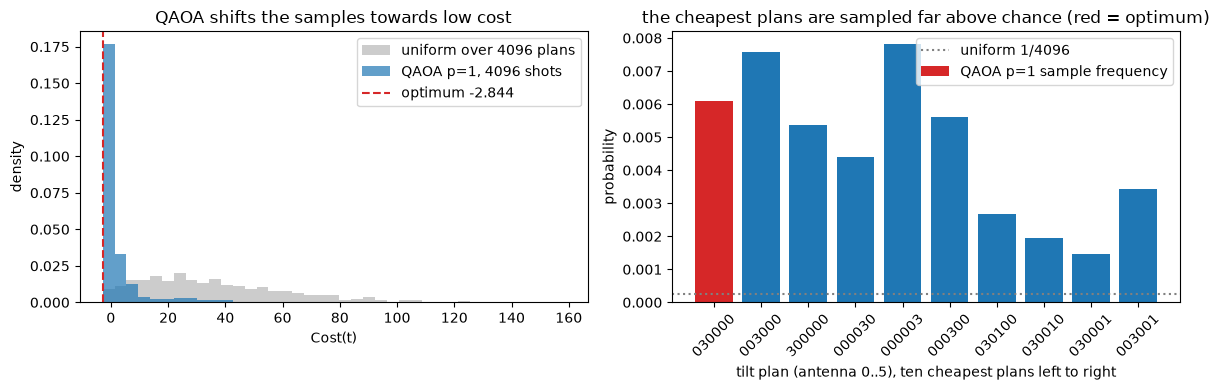

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sample_costs = np.repeat(
    [c for _, _, c in final["rows"]], [s for _, s, _ in final["rows"]]
)
bins = np.linspace(costs.min(), costs.max(), 40)
ax1.hist(
    costs,
    bins=bins,
    density=True,
    alpha=0.4,
    color="gray",
    label="uniform over 4096 plans",
)
ax1.hist(
    sample_costs,
    bins=bins,
    density=True,
    alpha=0.7,
    color="tab:blue",
    label=f"QAOA p=1, {NUM_SHOTS} shots",
)
ax1.axvline(OPT_C, color="tab:red", ls="--", label=f"optimum {OPT_C:.3f}")
ax1.set_xlabel("Cost(t)")
ax1.set_ylabel("density")
ax1.legend()
ax1.set_title("QAOA shifts the samples towards low cost")

sampled = {t: s for t, s, _ in final["rows"]}
cheapest = [all_plans[i] for i in np.argsort(costs)[:10]]
labels = ["".join(map(str, t)) for t in cheapest]
colors = ["tab:red" if t == OPT_T else "tab:blue" for t in cheapest]
ax2.bar(
    labels,
    [sampled.get(t, 0) / NUM_SHOTS for t in cheapest],
    color=colors,
    label="QAOA p=1 sample frequency",
)
ax2.axhline(1 / len(all_plans), color="gray", ls=":", label="uniform 1/4096")
ax2.set_ylabel("probability")
ax2.set_xlabel("tilt plan (antenna 0..5), ten cheapest plans left to right")
ax2.set_title("the cheapest plans are sampled far above chance (red = optimum)")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()
plt.tight_layout()
plt.show()

## 4. A second layer

With $p=2$ the statevector optimisation predicts $\langle \mathrm{Cost}\rangle = -0.38$ and
$P(\mathrm{Cost}<0) = 0.67$. The same Qmod is re-synthesised with `NUM_LAYERS = 2` and sampled at
the four predicted angles. Circuit depth doubles (184 CX gates instead of 92) and the number of
shots needed to see the optimum at least once with 95 % probability drops from about 12,300
(uniform) to about 450 ($p=1$) and 340 ($p=2$).

In [10]:
NUM_LAYERS = 2
WARM_START_P2 = [
    0.04115983314807234,
    1.1264484689522702,
    0.10989525180878296,
    0.5398234967992612,
]


@qfunc
def main(params: CArray[CReal, 2 * NUM_LAYERS], t: Output[TiltVars]) -> None:
    allocate(t)
    hadamard_transform(t)
    repeat(
        count=NUM_LAYERS,
        iteration=lambda i: (
            phase(tilt_cost(t), params[2 * i]),
            apply_to_all(lambda q: RX(params[2 * i + 1], q), t),
        ),
    )


qprog_p2 = synthesize(create_model(main))
m2 = get_transpiled_circuit_metrics(qprog_p2)
print(f"p=2 circuit: depth {m2.depth}, gates {dict(m2.count_ops)}")

with ExecutionSession(
    qprog_p2, execution_preferences=ExecutionPreferences(num_shots=NUM_SHOTS)
) as es2:
    s2 = summarize(es2.sample({"params": WARM_START_P2}))
print(
    f"p=2 hot start: <Cost> = {s2['expected_cost']:.4f}, P(cost<0) = {s2['p_cost_negative']:.3f}, "
    f"P(optimum) = {s2['p_optimum']:.4f}, best sampled plan {list(s2['best'][0])} cost {s2['best'][2]:.4f}"
)


def shots_for_95(p):
    return int(np.ceil(np.log(0.05) / np.log(1 - p))) if p > 0 else None


print(
    f"shots for 95% chance of sampling the optimum: uniform {shots_for_95(1 / len(all_plans))}, "
    f"p=1 {shots_for_95(final['p_optimum'])}, p=2 {shots_for_95(s2['p_optimum'])}"
)

p=2 circuit: depth 114, gates {'cx': 184, 'rz': 144, 'rx': 24, 'h': 12}


p=2 hot start: <Cost> = -0.3914, P(cost<0) = 0.666, P(optimum) = 0.0098, best sampled plan [0, 3, 0, 0, 0, 0] cost -2.8440
shots for 95% chance of sampling the optimum: uniform 12270, p=1 490, p=2 306


## 5. Why 2 qubits per antenna

A popular alternative packs the $3^3 = 27$ tilt configurations of a 3-sector site into 5 qubits
(32 states). It saves one qubit per site but 5 of the 32 basis states encode no plan, so the cost
needs penalty terms, the mixer leaks probability into invalid states (15.6 % at the uniform start
in the team's experiments, 3 % after optimisation) and the decoding is not a bijection. With one
`QNum` per antenna every basis state is a legal plan, the cost stays 2-local (only Z and ZZ
terms), the phase layer is exactly the polynomial above, and the sampled probability of the
optimum grew 27x over uniform instead of roughly 1x for the packed encoding.

## 6. Scaling the same model

The leaf shown here is a 12-qubit problem, but the Qmod is generic in `N_ANT` and `LEVELS`: a
cluster of 30 antennas with 4 levels is a 60-qubit program with $10^{18}$ plans, beyond exhaustive
enumeration; a city-scale deployment with 500 antennas would need 1000 qubits, where exact
statevector simulation ($2^{1000}$ amplitudes) is impossible and only a quantum processor can
sample the QAOA state. The hierarchical scheme (k-means grouping of interaction regions, one QAOA
per representative region, recursive refinement of the highest-variance group) keeps each leaf at
the size of the quantum hardware at hand.

## How this demo was built

The demo is the output of the **MantiQ Factor** production line, an agentic workflow that turns a
research description into a formally checked executable:

1. **Input / conversion**: the hackathon problem statement and the team's Hamiltonian write-up
   (PDF, Markdown) were converted to structured text.
2. **Understand**: the cost model above was extracted and the 2-qubit-per-antenna encoding chosen.
3. **Compute**: Wolfram Mathematica evaluated the exact 4096-state statevector, optimised the
   QAOA angles (hot start used above) and produced the reference statistics.
4. **Verify**: Lean 4 (with Mathlib) certified the optimum value, its lower bound and uniqueness,
   the encoding bijection and the unitarity of the phase layer (no `sorry`).
5. **Engineer / output**: the Qmod model in this notebook was generated, synthesised and executed
   on Classiq, and the sampled statistics were compared against the Wolfram prediction.

Sources, the Wolfram notebook, the Lean proofs and the presentation:
https://github.com/zuwasi/mantiq-factor-antenna-tilt (MIT). Hackathon repository (QUBIT 2026,
team Quantum Headache): https://github.com/zuwasi/quantum-headache-antenna-tilt. Tower data:
OpenCelliD, https://opencellid.org (CC BY-SA 4.0).